Description...

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import matplotlib.pyplot as plt
from   mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import os
import pandas as pd
# Styling Plot
crudo.pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# -------------------
# 1. FILE INFORMATION
# -------------------
# Directory
INPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/'
# Filename tags
VERSION_TAG = ['p2_icaros.h5', 'p2_zemrude.h5']
FILENAMES = [os.path.join(INPUT_DIR, 'merged_tagged_runs_castle_closed_RAS_' + filename) for filename in VERSION_TAG]

# ------------
# 2. SELECTION
# ------------
# HE scale correction
M_HE_SCALE_ICAROS = 4.80e-06
B_HE_SCALE_ICAROS = 0.0094      # in [MeV]

M_HE_SCALE_ZEMRUDE = 5.05e-06
B_HE_SCALE_ZEMRUDE = 0.0085     # in [MeV]

# DEP_CORRECTION = 0.0695         # in [MeV]

# ----- Trigger 2 Efficiency Cut ----- #
# Events with event-level energy below this are removed to account for trigger efficiency
TRG2_THRESHOLD = 0.5        # in [MeV]

# -----------------
# 3. PLOT SETTINGS
# -----------------
# From merged_corr_time.txt
RAS_ON_CORRECTED_TIME  = 3485614.533823055      # in [s]

DEP_VALUE = 1.593       # MeV

# Geometric boundaries for event classification
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

### Load Merged/Tagged Dataframes

In [3]:
DATAFRAMES = {
                'icaros'  : {'duration': RAS_ON_CORRECTED_TIME, 'processed': pd.DataFrame(), 'inclusive': pd.DataFrame(), 'fiducial': pd.DataFrame()},
                'zemrude' : {'duration': RAS_ON_CORRECTED_TIME, 'processed': pd.DataFrame(), 'inclusive': pd.DataFrame(), 'fiducial': pd.DataFrame()}
             }

for i, city in enumerate(DATAFRAMES.keys()):
    df_processed = pd.read_hdf(FILENAMES[i], key='Events')

    print(f"From {city.upper()} dataset: {df_processed['global_event'].nunique()} events processed.")
    DATAFRAMES[city]['processed'] = df_processed

# print(DATAFRAMES)

From ICAROS dataset: 939953 events processed.
From ZEMRUDE dataset: 939953 events processed.


In [41]:
df_test = DATAFRAMES['icaros']['processed']
df_test

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q,run_number,global_event,particle,region,E_evt_mev
0,1058,38,1.090162e+06,77.117778,-214.456283,1184.913652,1165.845054,1203.139853,502.738258,1.090162e+06,...,9.738993e+05,175.000,54576.613281,1419485.875,215967.015625,15625,0,alpha,cathode,5.242177
2,3102,28,1.063609e+05,-362.215708,237.768672,136.875644,125.644926,149.560663,572.328604,1.063609e+05,...,9.785644e+04,308.825,39356.585938,1401523.000,60969.777344,15625,2,electron,anode,0.519932
3,5461,34,2.930445e+05,-224.451501,347.900128,347.248393,334.735754,368.464266,507.585595,2.930445e+05,...,2.333951e+05,151.000,23892.027344,1409484.875,69040.187500,15625,3,alpha,tube,1.416014
4,6126,34,2.222232e+05,-416.782295,-162.637478,542.408243,532.266397,555.681839,488.325226,2.222232e+05,...,1.639722e+05,173.375,13266.886719,1409479.750,52798.039062,15625,4,alpha,tube,1.076072
5,6133,22,1.988441e+05,-340.849546,-285.208331,285.555980,276.370095,299.708119,516.827419,1.988441e+05,...,1.499328e+05,157.375,16010.417969,1407488.000,47908.890625,15625,5,alpha,tube,0.963852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005692,1789053,29,1.057319e+06,84.104820,253.593496,1184.812047,1163.695637,1207.938333,506.672815,1.057319e+06,...,9.181305e+05,119.700,50818.015625,1419487.875,199074.328125,15737,939948,alpha,cathode,5.084531
1005693,1789270,26,1.080759e+06,143.225628,156.980626,1184.811827,1164.829003,1209.152468,500.123641,1.080759e+06,...,9.645358e+05,118.200,52852.453125,1419486.375,207234.468750,15737,939949,alpha,cathode,5.197043
1005694,1790145,32,9.455144e+05,-25.332984,110.444560,40.504870,19.056382,63.463104,520.044009,9.455144e+05,...,8.981901e+05,138.800,50272.562500,1417486.750,203066.671875,15737,939950,alpha,anode,4.547869
1005695,1790215,33,1.151936e+06,-15.738679,-138.647671,898.008044,878.418313,919.020439,499.423574,1.151936e+06,...,1.044777e+06,110.275,67887.304688,1415487.375,211491.031250,15737,939951,alpha,tube,5.538691


# Selection

## Trigger02 Cut: or energy window

In [4]:
init_counter, final_counter = 0, 0

for city in DATAFRAMES.keys():

    print(f"--- Trigger02 cut for {city.upper()} dataset ---")
    df_temp = DATAFRAMES[city]['processed']
    init_counter = df_temp['global_event'].nunique()

    # Apply HE scale parameters
    if city == 'icaros':
        M_HE_SCALE = M_HE_SCALE_ICAROS
        B_HE_SCALE = B_HE_SCALE_ICAROS
    elif city == 'zemrude':
        M_HE_SCALE = M_HE_SCALE_ZEMRUDE
        B_HE_SCALE = B_HE_SCALE_ZEMRUDE

    # Convert from [pe] to [MeV] using HE scale
    df_temp = crudo.ef.energy_pe_to_mev(df_temp, slope=M_HE_SCALE, intercept=B_HE_SCALE, input_column='E_evt_pe', output_column='E_evt_mev')

    # Trigger2 efficiency cut
    df_temp = df_temp[df_temp['E_evt_mev'] >= TRG2_THRESHOLD].copy()
    final_counter = df_temp['global_event'].nunique()

    print(f"  After selection: {final_counter} events ({final_counter/init_counter:.2%})\n")
    DATAFRAMES[city]['processed'] = df_temp

--- Trigger02 cut for ICAROS dataset ---
  After selection: 771069 events (82.03%)

--- Trigger02 cut for ZEMRUDE dataset ---
  After selection: 757122 events (80.55%)



## Inclusive Electrons

In [5]:
init_counter, final_counter = 0, 0

for city in DATAFRAMES.keys():

    print(f"--- Electron cut for {city.upper()} dataset ---")
    df_temp = DATAFRAMES[city]['processed']
    init_counter = df_temp['global_event'].nunique()

    # Select only electron-like particles
    df_temp = df_temp[df_temp['particle'] == 'electron'].copy()
    final_counter = df_temp['global_event'].nunique()

    print(f"  After selection: {final_counter} events ({final_counter/init_counter:.2%})\n")
    DATAFRAMES[city]['inclusive'] = df_temp

--- Electron cut for ICAROS dataset ---
  After selection: 121862 events (15.80%)

--- Electron cut for ZEMRUDE dataset ---
  After selection: 115672 events (15.28%)



## Fiducial Electrons

### $nS2=1$

In [6]:
init_counter, final_counter = 0, 0

for city in DATAFRAMES.keys():

    print(f"--- nS2 = 1 cut for {city.upper()} dataset ---")
    df_temp = DATAFRAMES[city]['inclusive']
    init_counter = df_temp['global_event'].nunique()

    # nS2 = 1
    df_temp = df_temp[df_temp['nS2'] == 1].copy()
    final_counter = df_temp['global_event'].nunique()

    print(f"  After selection: {final_counter} events ({final_counter/init_counter:.2%})\n")
    DATAFRAMES[city]['fiducial'] = df_temp

--- nS2 = 1 cut for ICAROS dataset ---
  After selection: 107655 events (88.34%)

--- nS2 = 1 cut for ZEMRUDE dataset ---
  After selection: 101981 events (88.16%)



### Fiducial Volume

In [7]:
init_counter, final_counter = 0, 0

for city in DATAFRAMES.keys():

    print(f"--- Fiducial electrons cut for {city.upper()} dataset ---")
    df_temp = DATAFRAMES[city]['fiducial']
    init_counter = df_temp['global_event'].nunique()

    # Fiducial volume
    df_temp = df_temp[df_temp['region'] == 'fiducial'].copy()
    final_counter = df_temp['global_event'].nunique()

    print(f"  After selection: {final_counter} events ({final_counter/init_counter:.2%})\n")
    DATAFRAMES[city]['fiducial'] = df_temp

--- Fiducial electrons cut for ICAROS dataset ---
  After selection: 8286 events (7.70%)

--- Fiducial electrons cut for ZEMRUDE dataset ---
  After selection: 7798 events (7.65%)



# Energy Analysis

In [40]:
FIDU_ICAROS_DF

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q,run_number,global_event,particle,region,E_evt_mev
32,26181,30,130226.652027,38.731563,247.491677,318.854523,261.444088,381.408775,339.263506,130226.652027,...,121990.390625,266.600,5530.603027,1405481.375,57230.261719,15625,32,electron,fiducial,0.634488
192,142283,20,154278.189703,-271.675726,-59.179475,896.531245,843.757979,926.152797,374.955099,154278.189703,...,142327.750000,135.875,4530.961914,1405485.500,39192.679688,15625,181,electron,fiducial,0.749935
267,199193,26,232393.642303,43.976063,194.895827,280.910182,235.023311,341.368466,381.818964,232393.642303,...,219325.640625,213.550,4565.887695,1407481.375,64967.660156,15625,252,electron,fiducial,1.124889
281,212990,24,173860.064759,62.134601,301.738638,272.777708,240.952021,305.925847,412.811829,173860.064759,...,162202.437500,196.800,5299.647949,1407487.500,51799.054688,15625,266,electron,fiducial,0.843928
452,347677,33,495182.132632,147.684626,-101.292176,958.884621,835.276113,1090.626492,451.624586,495182.132632,...,462114.281250,445.400,6312.110352,1363481.250,140014.281250,15625,433,electron,fiducial,2.386274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005370,1474536,23,107714.537244,195.803879,-1.364845,184.950540,161.834904,219.547921,304.754838,107714.537244,...,102148.726562,210.400,5969.041504,1408489.875,45562.855469,15737,939661,electron,fiducial,0.526430
1005467,1568980,19,219427.325421,235.462227,-128.380736,429.616609,395.614562,463.994758,392.562092,219427.325421,...,205090.671875,260.000,4540.296387,1434492.625,72377.156250,15737,939747,electron,fiducial,1.062651
1005504,1609104,32,114725.809834,204.526688,-179.354956,120.121651,93.519908,144.507873,372.106317,114725.809834,...,110507.406250,134.000,8318.607422,1409479.375,32772.726562,15737,939783,electron,fiducial,0.560084
1005558,1662052,33,117331.260518,-185.595616,51.328759,320.744639,271.329848,363.594316,334.172285,117331.260518,...,112548.640625,216.000,4964.442383,1324490.375,50097.218750,15737,939830,electron,fiducial,0.572590



ICAROS:
  Counts = 8285, corr. time = 3485614.53 s | Rate = 2.3769 mHz
  Center of the DEP bin: 1.6500 MeV
  Shift value: 0.0570 MeV

ZEMRUDE:
  Counts = 7796, corr. time = 3485614.53 s | Rate = 2.2366 mHz
  Center of the DEP bin: 1.6100 MeV
  Shift value: 0.0170 MeV


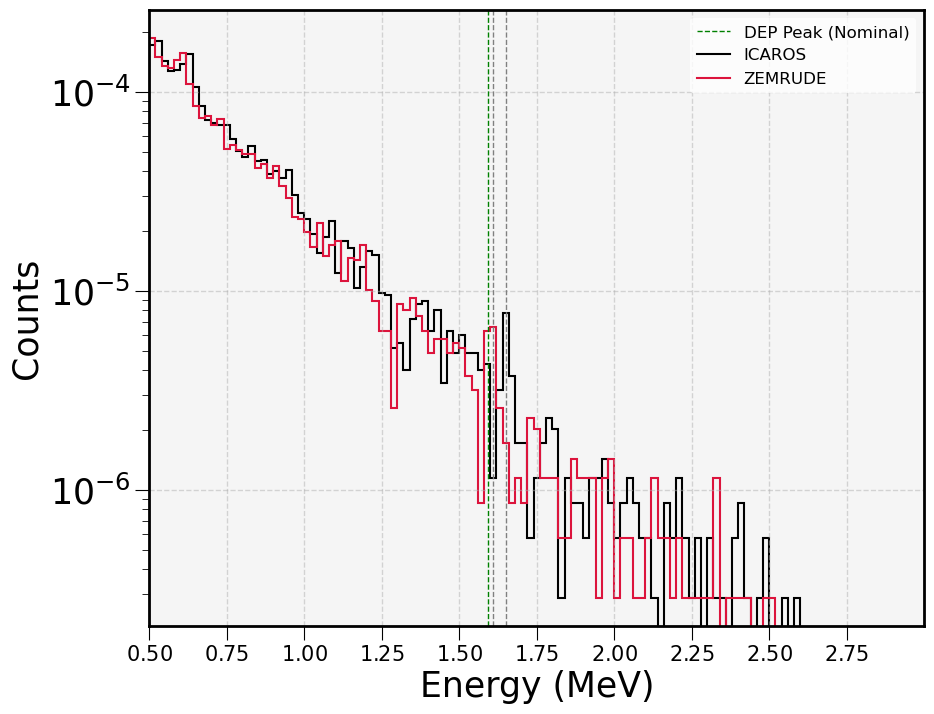

In [18]:
# Global
n_bins = 125
DEP_peak_hist = {}

# ----- Define the Binning ----- #
# Dataframes
FIDU_ICAROS_DF  = DATAFRAMES['icaros']['fiducial']
hist_range = (FIDU_ICAROS_DF['E_evt_mev'].min(), 3)
_, plot_edges = np.histogram(FIDU_ICAROS_DF['E_evt_mev'].unique(), bins=n_bins, range=hist_range)

for i, city in enumerate(DATAFRAMES.keys()):

    dataframe = DATAFRAMES[city]['fiducial']

    # Variable
    # E_evt = dataframe['E_evt_mev'].unique() - shift_value
    E_evt = dataframe['E_evt_mev'].unique()

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    rate = counts / (RAS_ON_CORRECTED_TIME)     # in [Hz]
    print(f"\n{city.upper()}:\n  Counts = {counts.sum()}, corr. time = {RAS_ON_CORRECTED_TIME:.2f} s | Rate = {rate.sum()*1e3:.4f} mHz")

    # ----- DEP Histogram Peak ----- #
    mask = (bin_edges[:-1] >= 1.55) & (bin_edges[:-1] <= 1.75)  
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Find the bin with the highest count in the specified range
    peak_bin_index  = np.argmax(counts[mask])
    peak_bin_center = bin_centers[mask][peak_bin_index]
    shift_value = peak_bin_center - DEP_VALUE
    DEP_peak_hist[city] = peak_bin_center
    print(f"  Center of the DEP bin: {peak_bin_center:.4f} MeV")
    print(f"  Shift value: {shift_value:.4f} MeV")
    
    # ----- Plotting ----- #
    # Data
    plt.stairs(rate, bin_edges, label=f'{city.upper()}', 
               fill=False, lw=1.5, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])
    # line
    plt.axvline(peak_bin_center, c='gray', ls='--', lw=1.0)

# Lines
plt.axvline(x=DEP_VALUE, c='green', ls='--', lw=1.0, label='DEP Peak (Nominal)')

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3.0)
plt.xticks(np.arange(0.5, 3.0, 0.25))
plt.xticks(fontsize=15)
plt.ylabel('Counts')
# plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper right', fontsize=12)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_Inclusive_Fiducial.pdf')
plt.show()


ICAROS:
  Fit range = (1.5500, 1.7500) MeV
    μ guess = 1.6500 MeV
  Fit results:
    μ = (1.6558 ± 0.0014) MeV
    σ = (0.0042 ± 0.0014) MeV
    R(%) = (0.60 ± 0.20)%

ZEMRUDE:
  Fit range = (1.5500, 1.7500) MeV
    μ guess = 1.6100 MeV
  Fit results:
    μ = (1.5999 ± 0.0015) MeV
    σ = (0.0074 ± 0.0016) MeV
    R(%) = (1.09 ± 0.23)%


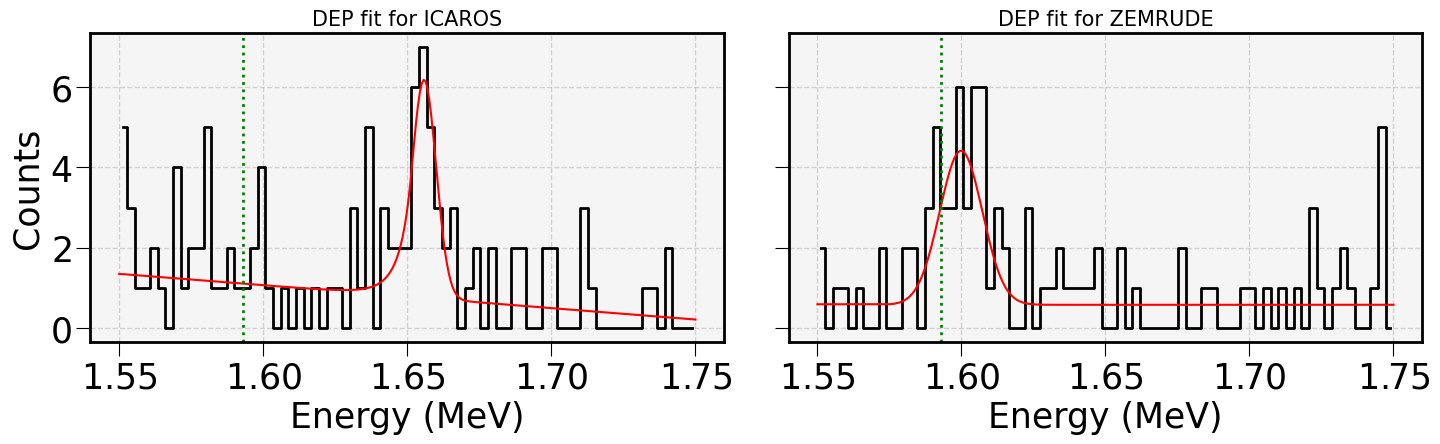

In [39]:
# Global
n_bins = 75
fig, axes = plt.subplots(1, len(DATAFRAMES.keys()), figsize=(15, 5), sharey=True)

for i, (city, ax) in enumerate(zip(DATAFRAMES.keys(), axes)):
   dataframe = DATAFRAMES[city]['fiducial']
   mu_guess = DEP_peak_hist[city]

   print(f"\n{city.upper()}:")
   # ----- Fitting ----- #
   energy_data = dataframe['E_evt_mev'].unique()
   fit_range  = (peak_bin_center - 0.1, peak_bin_center + 0.1)
   print(f"  Fit range = ({fit_range[0]:.4f}, {fit_range[1]:.4f}) MeV")
   print(f"    μ guess = {mu_guess:.4f} MeV")
   popt, pcov, (hist_counts, hist_bins) = crudo.ff.fit_peak_crystal_ball(energy_data, mu_guess, fit_range, bins=n_bins)

   if popt is not None:

      # --- Plotting --- #
      # Data
      ax.step(hist_counts, hist_bins, where='mid', label='Data')
      
      # Fit
      fit_x = np.linspace(fit_range[0], fit_range[-1], 300)
      ax.plot(fit_x, crudo.ff.crystal_ball_with_linear_bg(fit_x, *popt),
              color='red', linestyle='-', lw=1.5)

      # Results
      mu, sigma = popt[1], abs(popt[2])
      mu_err, sigma_err = np.sqrt(pcov[1, 1]), np.sqrt(pcov[2, 2])
      res_cv = 2.355 * sigma / mu * 100
      res_err = res_cv * np.sqrt((sigma_err / sigma) ** 2 + (mu_err / mu) ** 2) if sigma > 0 else np.nan
      print(f"  Fit results:\n    μ = ({mu:.4f} ± {mu_err:.4f}) MeV\n    σ = ({sigma:.4f} ± {sigma_err:.4f}) MeV\n    R(%) = ({res_cv:.2f} ± {res_err:.2f})%")

   # --- Styling --- #
   ax.axvline(DEP_VALUE, c='green', ls=':', lw=2)
   ax.set_title(f'DEP fit for {city.upper()}', fontsize=15)
   ax.set_xlabel('Energy (MeV)')
   ax.grid(True)
   ax.set_facecolor("whitesmoke")

axes[0].set_ylabel('Counts')
plt.tight_layout()
plt.show()